In [10]:
import yfinance as yf
yf.__version__


'1.0'

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

sp500 = yf.download("^GSPC", start="2000-01-01", auto_adjust=False)
sp500.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2000-01-03,1455.219971,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [12]:
sp500.index.min(), sp500.index.max(), sp500.shape


(Timestamp('2000-01-03 00:00:00'), Timestamp('2026-01-09 00:00:00'), (6545, 6))

In [13]:
sp500["return"] = sp500["Close"].pct_change()
sp500[["Close", "return"]].tail()


Price,Close,return
Ticker,^GSPC,
Date,,
2026-01-05,6902.049805,0.006354
2026-01-06,6944.819824,0.006197
2026-01-07,6920.930176,-0.003440
2026-01-08,6921.459961,0.000077
2026-01-09,6966.279785,0.006475


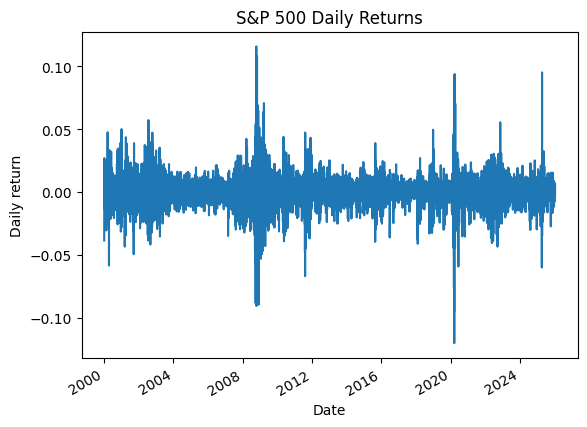

In [14]:
sp500["return"].plot(title="S&P 500 Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily return")
plt.show()


In [15]:
sp500.head()

Price,Adj Close,Close,High,Low,Open,Volume,return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,
Date,,,,,,,
2000-01-03,1455.219971,1455.219971,1478.000000,1438.359985,1469.250000,931800000,NaN
2000-01-04,1399.420044,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,-0.038345
2000-01-05,1402.109985,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,0.001922
2000-01-06,1403.449951,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,0.000956
2000-01-07,1441.469971,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,0.027090


In [16]:
btc = yf.download("BTC-USD", start="2015-01-01", auto_adjust=False)
btc.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2015-01-01,314.248993,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,274.473999,278.341003,265.084015,265.084015,43962800


In [17]:
btc["return"] = btc["Close"].pct_change()
btc[["Close", "return"]].tail()


Price,Close,return
Ticker,BTC-USD,
Date,,
2026-01-05,93882.554688,0.027010
2026-01-06,93729.031250,-0.001635
2026-01-07,91308.054688,-0.025830
2026-01-08,91027.125000,-0.003077
2026-01-10,90470.281250,-0.006117


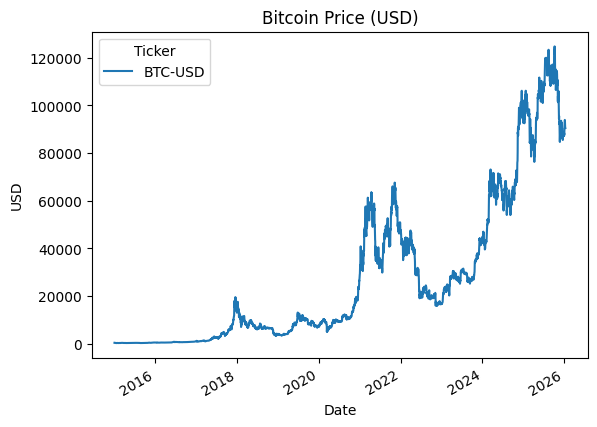

In [18]:
btc["Close"].plot(title="Bitcoin Price (USD)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.show()


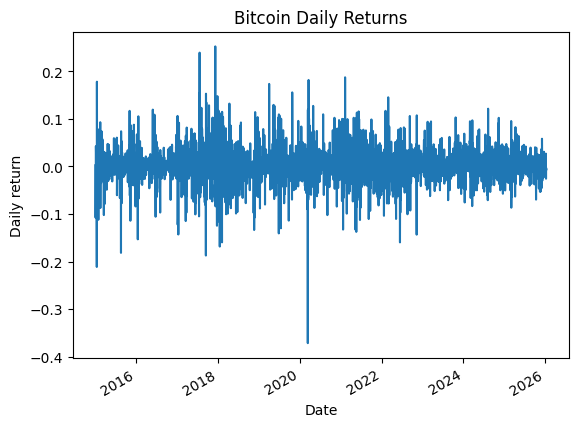

In [19]:
btc["return"].plot(title="Bitcoin Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily return")
plt.show()


In [20]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

start_date = "2016-01-01"

sp500 = yf.download("^GSPC", start=start_date, auto_adjust=False)
btc = yf.download("BTC-USD", start=start_date, auto_adjust=False)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [21]:
sp500["return"] = sp500["Close"].pct_change()
btc["return"] = btc["Close"].pct_change()



In [22]:
window = 30

sp500["volatility_30d"] = sp500["return"].rolling(window).std()
btc["volatility_30d"] = btc["return"].rolling(window).std()


In [23]:
vol_df = pd.DataFrame({
    "S&P 500": sp500["volatility_30d"],
    "Bitcoin": btc["volatility_30d"]
}).dropna()


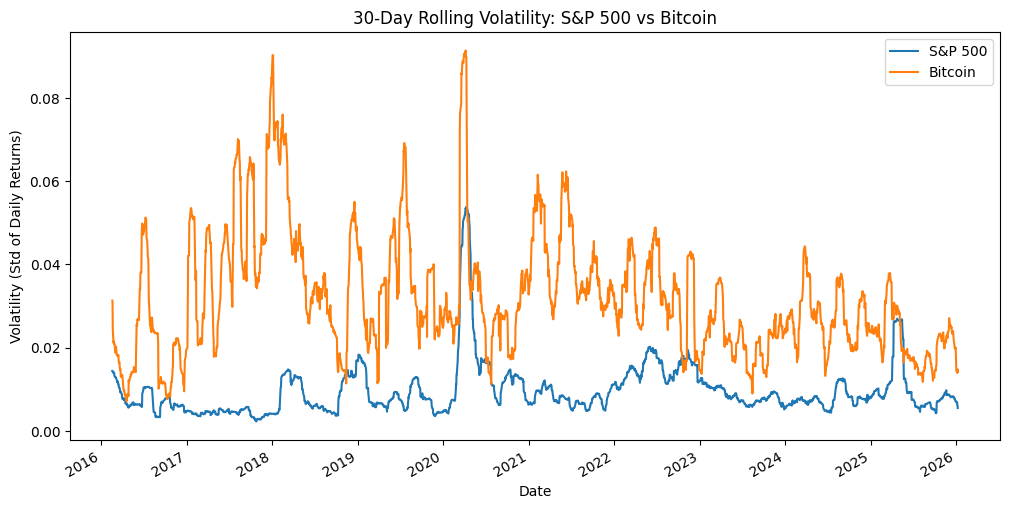

In [24]:
vol_df.plot(figsize=(12,6), title="30-Day Rolling Volatility: S&P 500 vs Bitcoin")
plt.xlabel("Date")
plt.ylabel("Volatility (Std of Daily Returns)")
plt.show()


In [25]:
start_date = "2016-01-01"

sp500 = yf.download("^GSPC", start=start_date)
btc = yf.download("BTC-USD", start=start_date)

sp500["return"] = sp500["Close"].pct_change()
btc["return"] = btc["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [26]:
returns_df = pd.DataFrame({
    "S&P 500": sp500["return"],
    "Bitcoin": btc["return"]
}).dropna()


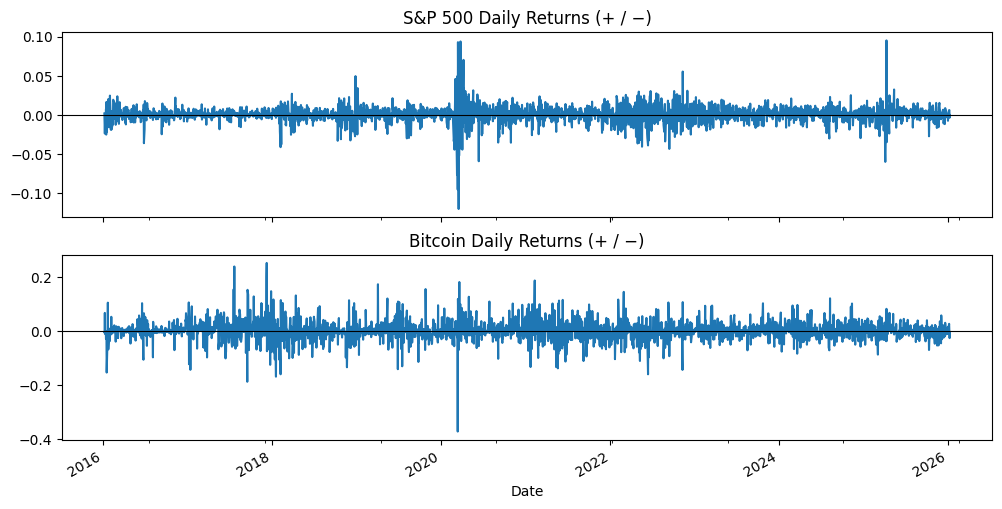

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

returns_df["S&P 500"].plot(ax=axes[0], title="S&P 500 Daily Returns (+ / −)")
axes[0].axhline(0, color="black", linewidth=0.8)

returns_df["Bitcoin"].plot(ax=axes[1], title="Bitcoin Daily Returns (+ / −)")
axes[1].axhline(0, color="black", linewidth=0.8)

plt.xlabel("Date")
plt.show()


In [28]:
returns_df.head()


,S&P 500,Bitcoin
Date,,
2016-01-05,0.002012,-0.002611
2016-01-06,-0.013115,-0.006609
2016-01-07,-0.023700,0.067450
2016-01-08,-0.010838,-0.010519
2016-01-11,0.000853,0.000975


In [29]:
max_abs_return = returns_df.abs().max().max()
max_abs_return


np.float64(0.37169538560117077)

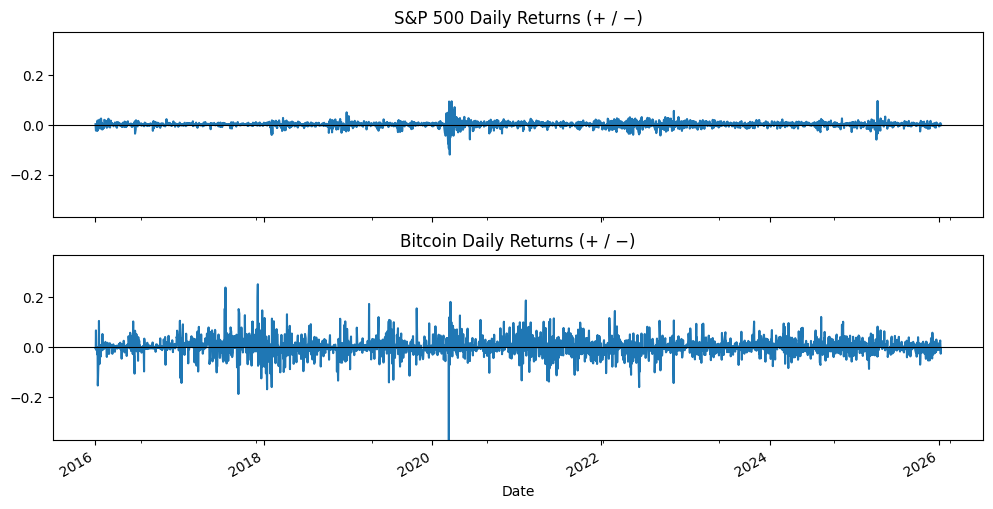

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

returns_df["S&P 500"].plot(ax=axes[0], title="S&P 500 Daily Returns (+ / −)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylim(-max_abs_return, max_abs_return)

returns_df["Bitcoin"].plot(ax=axes[1], title="Bitcoin Daily Returns (+ / −)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylim(-max_abs_return, max_abs_return)

plt.xlabel("Date")
plt.show()


In [31]:
eth = yf.download("ETH-USD", start="2016-01-01")
eth["return"] = eth["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed


In [32]:
returns_df = pd.DataFrame({
    "S&P 500": sp500["return"],
    "Bitcoin": btc["return"],
    "Ethereum": eth["return"]
}).dropna()


In [33]:
max_abs_return = returns_df.abs().max().max()
max_abs_return


np.float64(0.42347221465293294)

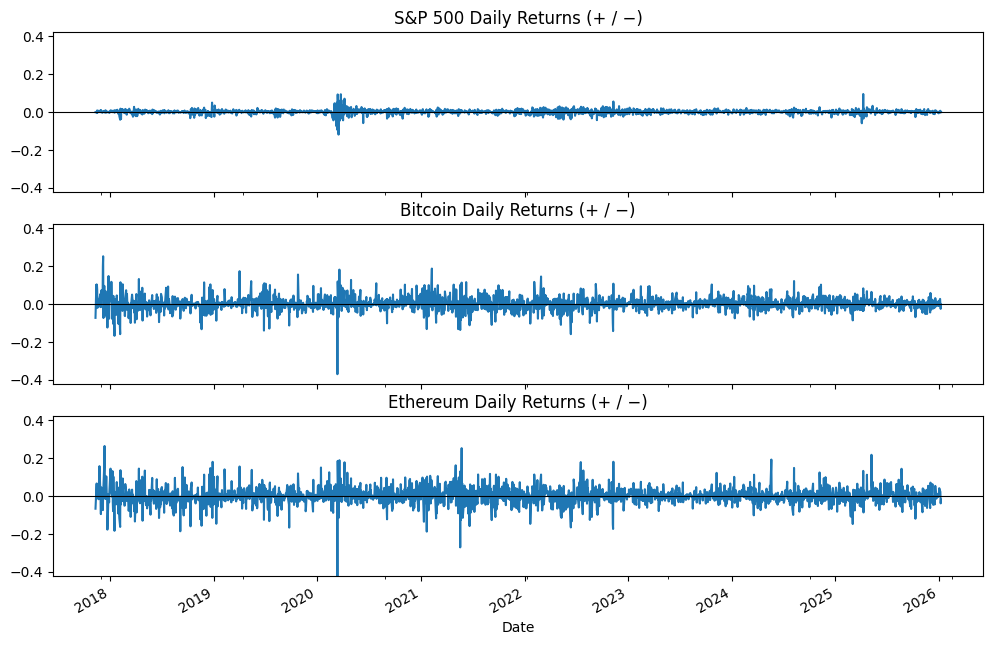

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(12,8), sharex=True)

returns_df["S&P 500"].plot(ax=axes[0], title="S&P 500 Daily Returns (+ / −)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylim(-max_abs_return, max_abs_return)

returns_df["Bitcoin"].plot(ax=axes[1], title="Bitcoin Daily Returns (+ / −)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylim(-max_abs_return, max_abs_return)

returns_df["Ethereum"].plot(ax=axes[2], title="Ethereum Daily Returns (+ / −)")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylim(-max_abs_return, max_abs_return)

plt.xlabel("Date")
plt.show()


In [35]:
start_date = "2016-01-01"

gold = yf.download("GC=F", start=start_date)       # Gold futures
dxy  = yf.download("DX-Y.NYB", start=start_date)   # US Dollar Index (DXY)

gold["return"] = gold["Close"].pct_change()
dxy["return"]  = dxy["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [36]:
returns_df = pd.DataFrame({
    "S&P 500": sp500["return"],
    "Bitcoin": btc["return"],
    "Ethereum": eth["return"],
    "Gold": gold["return"],
    "US Dollar Index (DXY)": dxy["return"],
}).dropna()

returns_df.head()


,S&P 500,Bitcoin,Ethereum,Gold,US Dollar Index (DXY)
Date,,,,,
2017-11-10,-0.000898,-0.073554,-0.067411,-0.010268,-0.000529
2017-11-13,0.000984,0.102422,0.028606,0.003851,0.001059
2017-11-14,-0.002310,0.011626,0.066037,0.003288,-0.006985
2017-11-15,-0.005526,0.102444,-0.012659,-0.003902,-0.000213
2017-11-16,0.008196,0.076023,-0.007298,0.000705,0.001279


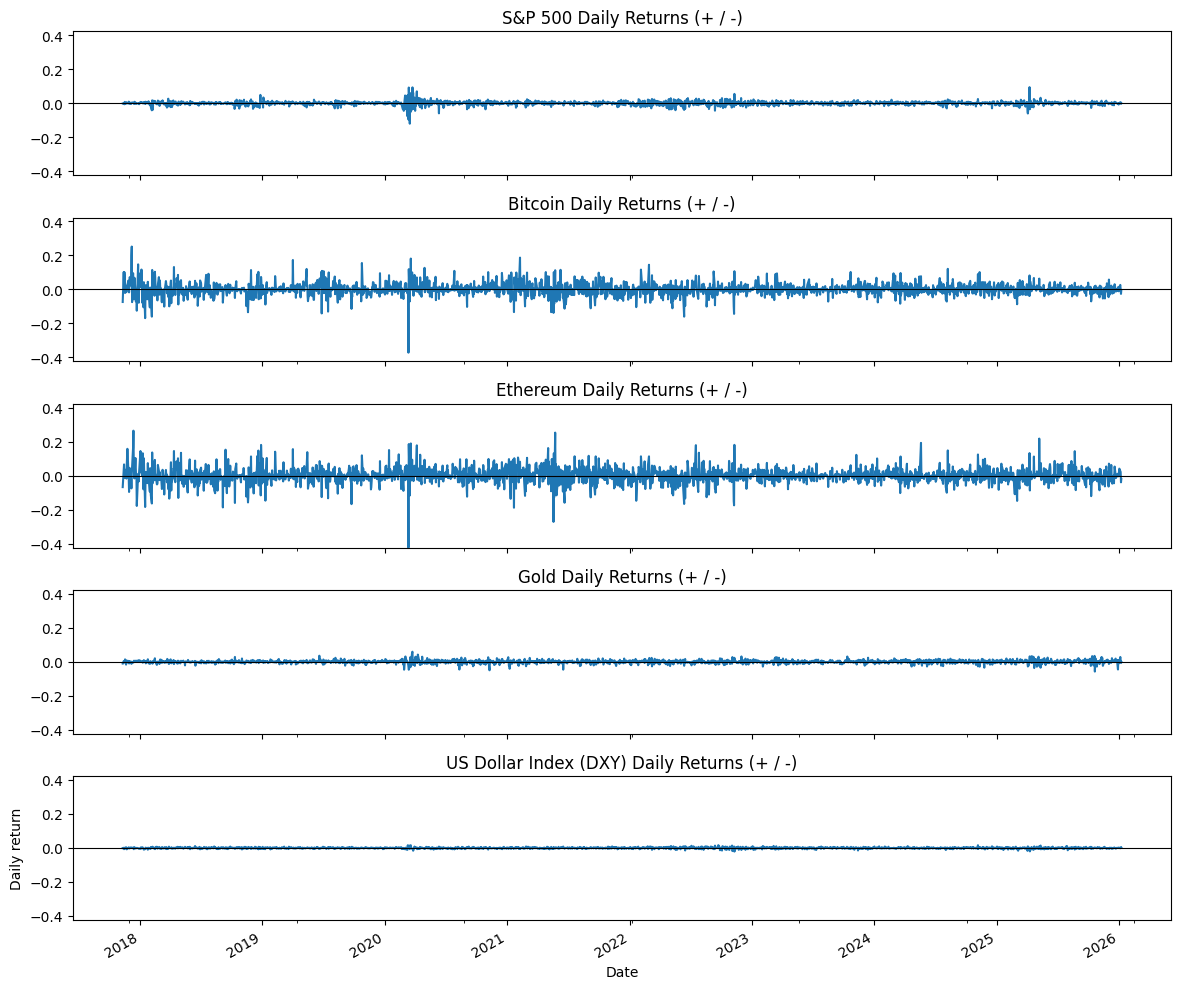

In [37]:
max_abs_return = returns_df.abs().max().max()

fig, axes = plt.subplots(5, 1, figsize=(12,10), sharex=True, sharey=True)

series_order = ["S&P 500", "Bitcoin", "Ethereum", "Gold", "US Dollar Index (DXY)"]

for ax, name in zip(axes, series_order):
    returns_df[name].plot(ax=ax, title=f"{name} Daily Returns (+ / -)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-max_abs_return, max_abs_return)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()


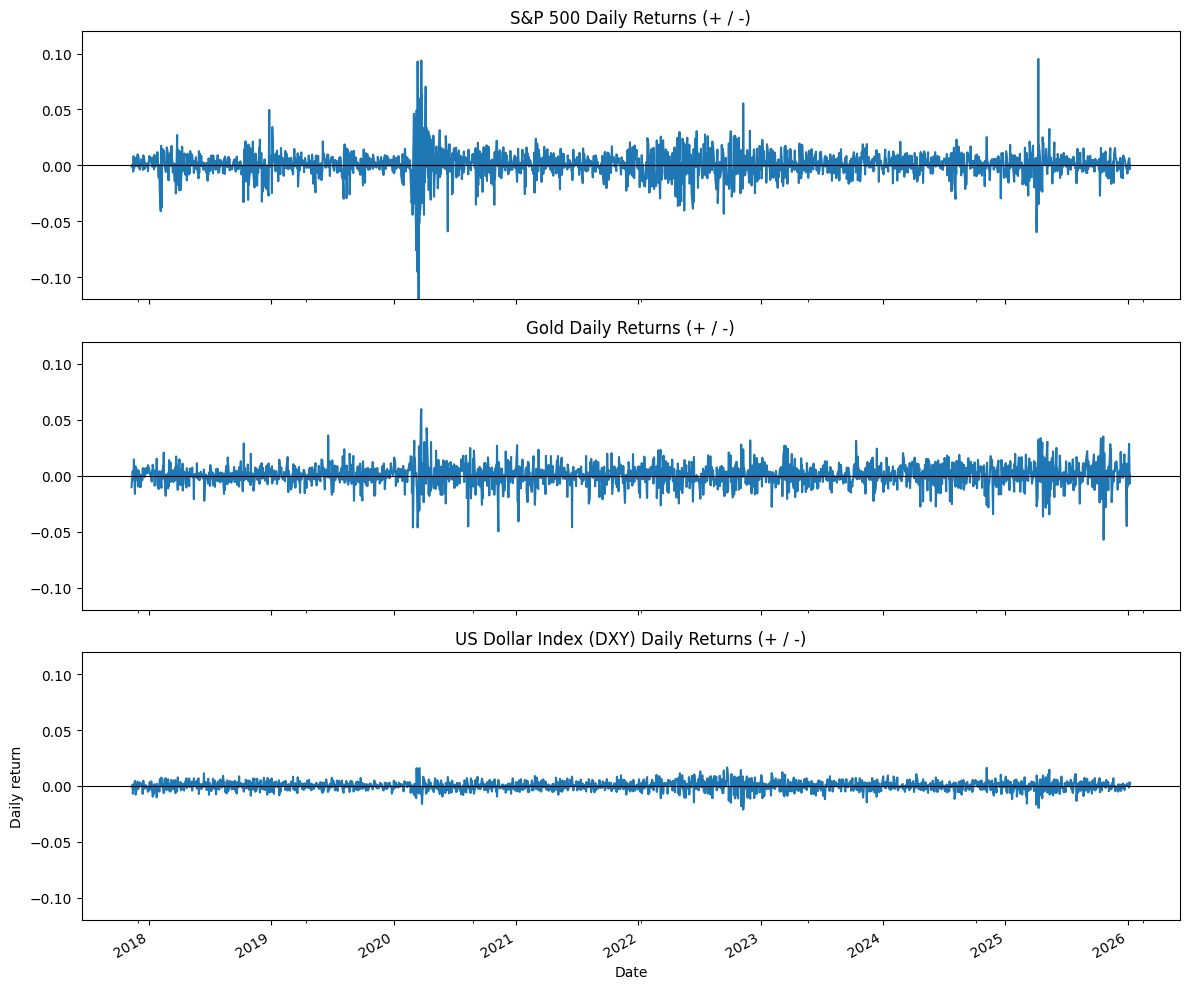

In [40]:
plot_cols = ["S&P 500", "Gold", "US Dollar Index (DXY)"]
max_abs_return = returns_df[plot_cols].abs().max().max()


fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True, sharey=True)

series_order = ["S&P 500","Gold", "US Dollar Index (DXY)"]

for ax, name in zip(axes, series_order):
    returns_df[name].plot(ax=ax, title=f"{name} Daily Returns (+ / -)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-max_abs_return, max_abs_return)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()

In [41]:
start_date = "2000-01-01"


In [42]:
sp500 = yf.download("^GSPC", start=start_date)
gold  = yf.download("GC=F", start=start_date)
dxy   = yf.download("DX-Y.NYB", start=start_date)

sp500["return"] = sp500["Close"].pct_change()
gold["return"]  = gold["Close"].pct_change()
dxy["return"]   = dxy["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [43]:
returns_df = pd.DataFrame({
    "S&P 500": sp500["return"],
    "Gold": gold["return"],
    "US Dollar Index (DXY)": dxy["return"]
}).dropna()


In [44]:
plot_cols = ["S&P 500", "Gold", "US Dollar Index (DXY)"]
limit = returns_df[plot_cols].abs().quantile(0.99).max()


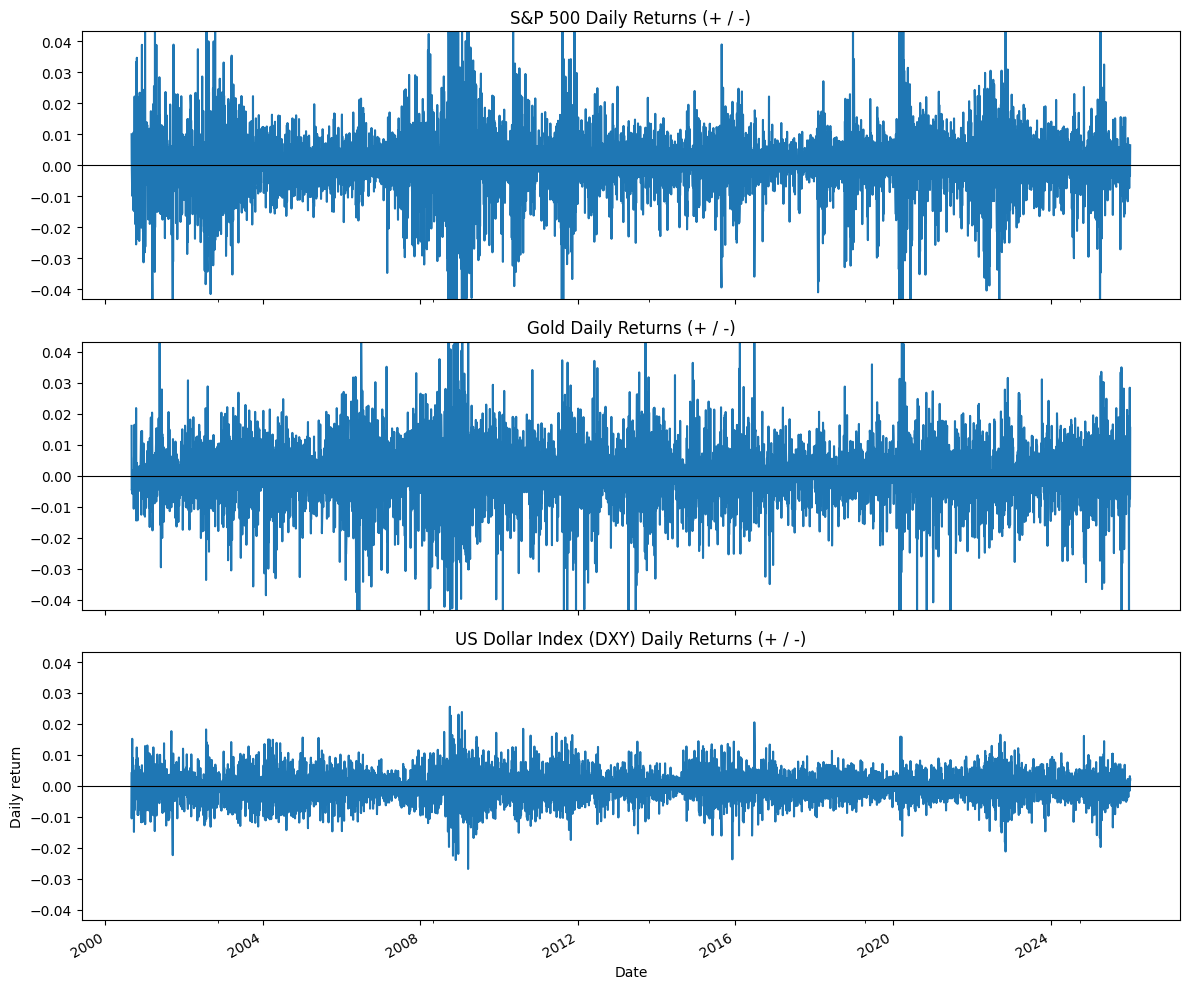

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(12,10), sharex=True, sharey=True)

for ax, name in zip(axes, plot_cols):
    returns_df[name].plot(ax=ax, title=f"{name} Daily Returns (+ / -)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-limit, limit)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()


In [46]:
start_date = "2016-01-01"

wtc = yf.download("WTC.AX", start=start_date)
sp500 = yf.download("^GSPC", start=start_date)
btc = yf.download("BTC-USD", start=start_date)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [47]:
wtc["return"] = wtc["Close"].pct_change()
sp500["return"] = sp500["Close"].pct_change()
btc["return"] = btc["Close"].pct_change()


In [48]:
returns_df = pd.DataFrame({
    "WiseTech Global (WTC)": wtc["return"],
    "S&P 500": sp500["return"],
    "Bitcoin": btc["return"]
}).dropna()


In [49]:
plot_cols = ["WiseTech Global (WTC)", "S&P 500", "Bitcoin"]
limit = returns_df[plot_cols].abs().quantile(0.99).max()
""

''

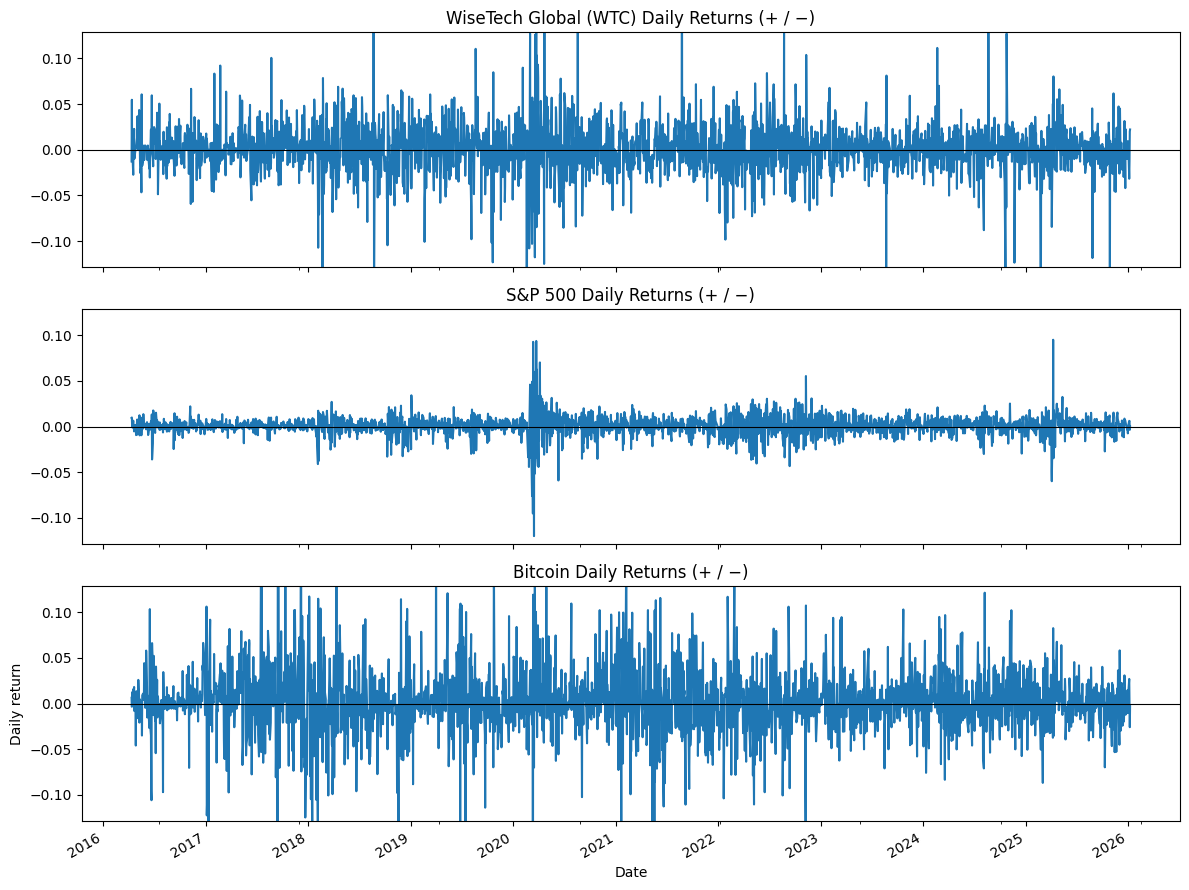

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(12,9), sharex=True, sharey=True)

for ax, name in zip(axes, plot_cols):
    returns_df[name].plot(ax=ax, title=f"{name} Daily Returns (+ / −)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-limit, limit)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()


In [51]:
start_date = "2016-01-01"

wtc = yf.download("WTC.AX", start=start_date)
btc = yf.download("BTC-USD", start=start_date)

wtc["return"] = wtc["Close"].pct_change()
btc["return"] = btc["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [52]:
returns_df = pd.DataFrame({
    "WiseTech Global": wtc["return"],
    "Bitcoin": btc["return"]
}).dropna()


In [53]:
plot_cols = ["WiseTech Global", "Bitcoin"]
limit = returns_df[plot_cols].abs().quantile(0.99).max()


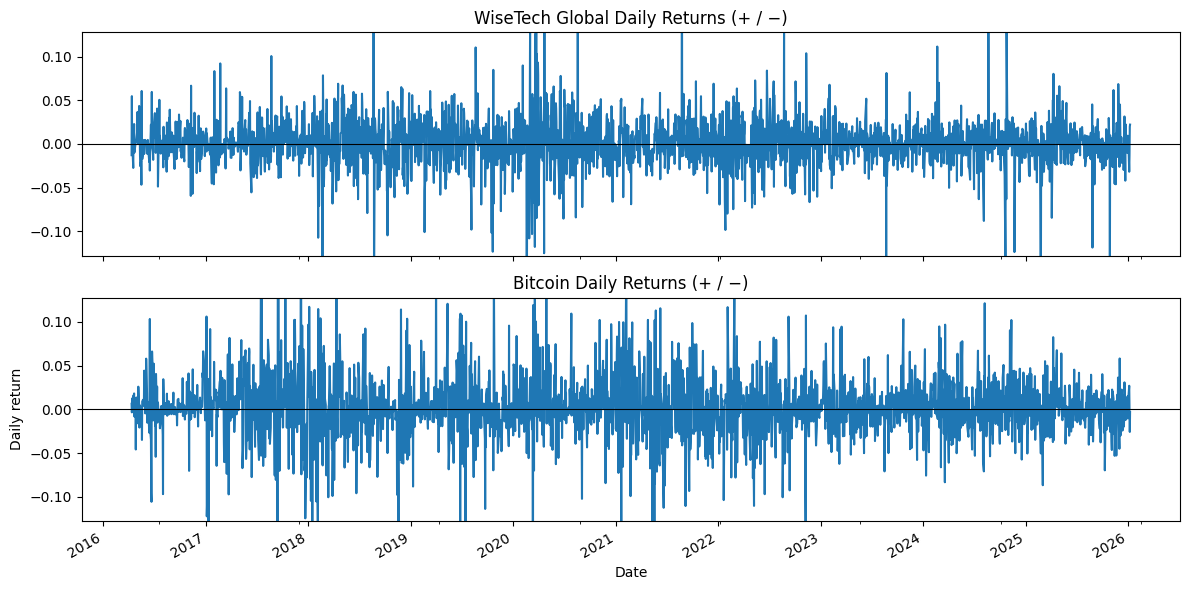

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True, sharey=True)

returns_df["WiseTech Global"].plot(
    ax=axes[0], title="WiseTech Global Daily Returns (+ / −)"
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylim(-limit, limit)

returns_df["Bitcoin"].plot(
    ax=axes[1], title="Bitcoin Daily Returns (+ / −)"
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylim(-limit, limit)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()


In [55]:
start_date = "2016-01-01"

tsla = yf.download("TSLA", start=start_date)
aapl = yf.download("AAPL", start=start_date)

tsla["return"] = tsla["Close"].pct_change()
aapl["return"] = aapl["Close"].pct_change()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [56]:
returns_df = pd.DataFrame({
    "WiseTech Global": wtc["return"],
    "Bitcoin": btc["return"],
    "Tesla": tsla["return"],
    "Apple": aapl["return"],
}).dropna()


In [57]:
plot_cols = ["WiseTech Global", "Bitcoin", "Tesla", "Apple"]
limit = returns_df[plot_cols].abs().quantile(0.99).max()


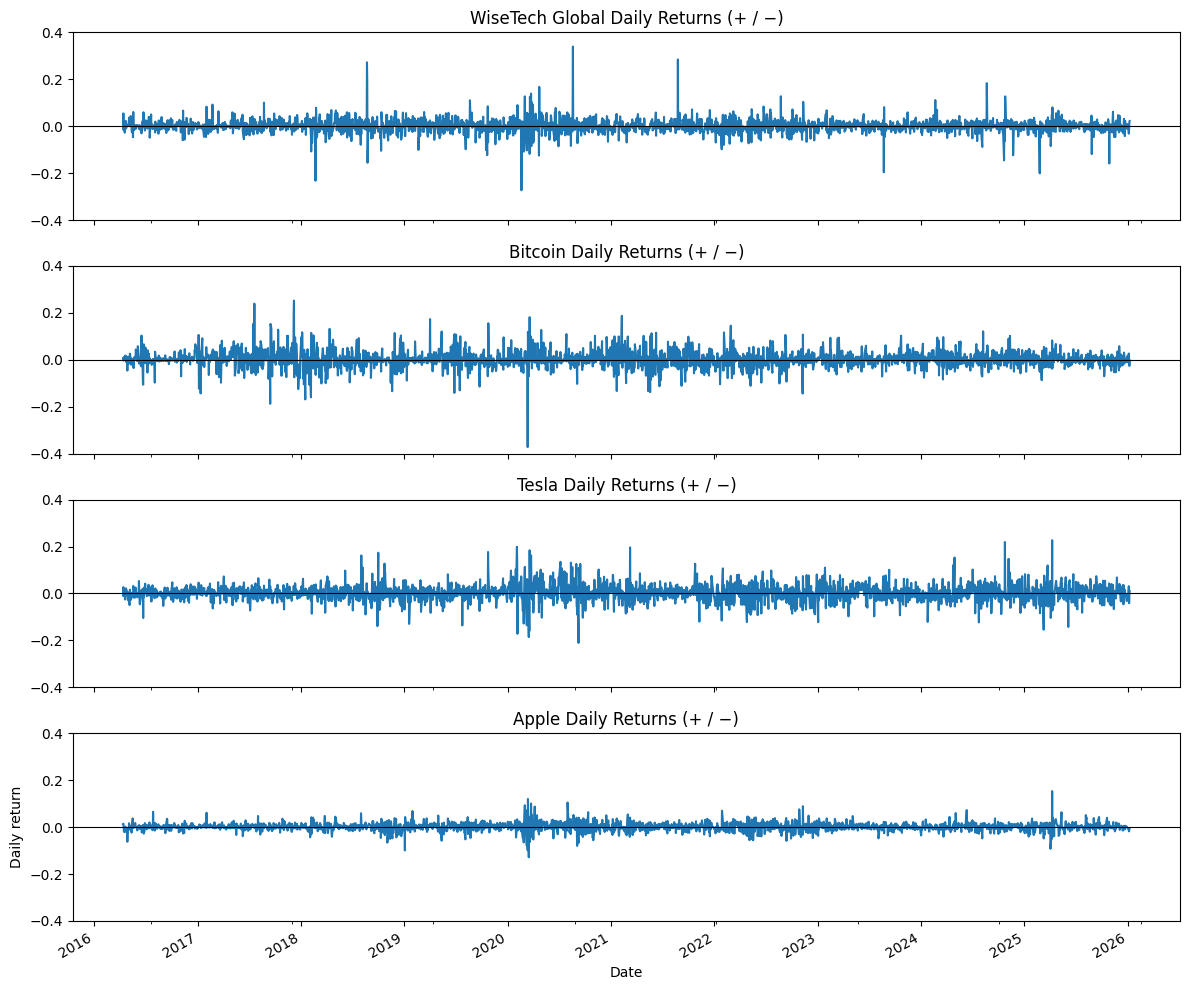

In [60]:
fig, axes = plt.subplots(4, 1, figsize=(12,10), sharex=True, sharey=True)

for ax, name in zip(axes, plot_cols):
    returns_df[name].plot(ax=ax, title=f"{name} Daily Returns (+ / −)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-0.4, 0.4)

plt.xlabel("Date")
plt.ylabel("Daily return")
plt.tight_layout()
plt.show()
